# SQLStorm StackOverflow — queries with the same or similar output

Many StackOverflow queries return the same data in a different form: the same rows under other column
names, in another column or row order, cut by a smaller `LIMIT`, or with fewer columns. This notebook finds
those relations from the saved result rows and asks, for each kind, **does the energy differ, and what in the
plan and the SQL goes with that**.

| data | source |
|---|---|
| result rows | `output_runner` run, laptop 1 → `cache/outputs_cache/stackoverflow_1gb/` (pulled by `sqlstorm_outputs.ipynb`) |
| plans | `plan_builder` `EXPLAIN (ANALYZE, BUFFERS)` run, laptop 2 → `cache/plans_cache/` |
| energy | laptop 2 slope energy per copy, `export/sqlstorm_stackoverflow_energy_laptop2/query_energy.csv` |
| SQL and canonical forms | `cache/sqlstorm_cache/stackoverflow/queries/`, `csv/sqlstorm_stackoverflow_sqlglot.csv` (§3d of `sqlstorm_outputs.ipynb`) |

**Unit: the SQL variant.** Queries with the same sqlglot canonical form are copies of one SQL text; they were
checked to return the same rows (`sqlstorm_outputs.ipynb` §3d) and they have the same plan (§3e). Each copy
set counts once, with the median energy of its copies, so a pair below is always two *different* SQL texts.

Sections: 1 outputs and variants, 2 finding the relations, 3 same output — energy, plans and SQL (3b: same plan
but different output), 4 renamed
versions, 5 limited versions, 6 narrower versions (fewer columns), 7 subsets, 8 export
(`csv/sqlstorm_stackoverflow_output_relations.csv`), 9 text files of the largest gaps per same-plan,
same-plan-shape and same-output group (`export/similar_output_pairs/`).

## 0. Setup and plans

Result rows and queries come from the caches of the other notebooks (run `sqlstorm_analysis.ipynb` and
`sqlstorm_outputs.ipynb` first). Plans are pulled from laptop 2 if the cache is incomplete.

In [1]:
# %pip install paramiko pandas matplotlib
import collections, difflib, itertools
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
                     "axes.grid": True, "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures/similar_output"); FIG.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


ODIR = Path("cache/outputs_cache/stackoverflow_1gb")
QDIR = Path("cache/sqlstorm_cache/stackoverflow/queries")
SGCSV = Path("csv/sqlstorm_stackoverflow_sqlglot.csv")
FEATCSV = Path("csv/sqlstorm_stackoverflow_query_features.csv")
ECSV = Path("export/sqlstorm_stackoverflow_energy_laptop2/query_energy.csv")
for p, nbk in [(ODIR, "sqlstorm_outputs"), (QDIR, "sqlstorm_analysis"), (SGCSV, "sqlstorm_outputs"),
               (FEATCSV, "sqlstorm_analysis"), (ECSV, "laptop2_export")]:
    assert p.exists(), f"{p} missing — run {nbk}.ipynb first"

In [2]:
import re, hashlib, tarfile, time
from pathlib import Path

PLAN_HOST = "192.168.1.59"                       # laptop 2 ran plan_builder (user/password as above)
PLAN_DB = "stackoverflow_1gb"
PLAN_CACHE = Path("cache/plans_cache")
PLAN_DIR = PLAN_CACHE / "plans" / PLAN_DB
PLAN_EXPECT = 11794


def pull_plans():
    if len(list(PLAN_DIR.glob("*.txt"))) >= PLAN_EXPECT:
        return f"cache ({len(list(PLAN_DIR.glob('*.txt')))} files)"
    try:
        import paramiko
        cl = paramiko.SSHClient()
        cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        cl.connect(PLAN_HOST, username="user01", password="a", timeout=45, banner_timeout=45, auth_timeout=45)
        try:
            _, out, _ = cl.exec_command(f"cd /home/user01/GreenSQL && tar -czf - plans/{PLAN_DB} "
                                        f"logs/plans/console_{PLAN_DB}.log")
            with tarfile.open(fileobj=out, mode="r|gz") as tf:
                tf.extractall(PLAN_CACHE, filter="data")
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        if not PLAN_DIR.exists():
            raise RuntimeError(f"{exc}\nNo plan cache at '{PLAN_DIR}/'.") from exc
        return f"cache (pull failed: {type(exc).__name__})"


NODE_RE = re.compile(r"^(?P<ind>\s*)(?:->\s+)?(?P<op>[A-Z][^(]*?)\s+\(cost=(?P<c0>[\d.]+)\.\.(?P<c1>[\d.]+) rows=(?P<erows>\d+) width=\d+\)"
                     r"\s+(?:\(actual (?:time=[\d.]+\.\.[\d.]+ )?rows=(?P<arows>[\d.]+) loops=(?P<loops>\d+)\)|(?P<never>\(never executed\)))")
LABEL_RE = re.compile(r"^\s*(CTE \S+|InitPlan \d+|SubPlan \d+)")
SCAN_RE = re.compile(r"^(?P<kind>.*?)(?: using (?P<index>\S+))? on (?P<rel>\S+)(?: (?P<alias>\S+))?$")
DETAIL_KEYS = ("Sort Key", "Hash Cond", "Merge Cond", "Join Filter", "Filter", "Index Cond", "Group Key",
               "Recheck Cond", "Run Condition", "One-Time Filter", "Presorted Key", "Cache Key", "Window")


def parse_plan(txt):
    """EXPLAIN ANALYZE text -> dict(nodes=[...], exec_ms, plan_ms, ...) or None if no plan."""
    if "QUERY PLAN" not in txt[:2000]:
        return None
    nodes, labels = [], []
    pending_label = None
    for line in txt.split("\n")[2:]:
        if line.startswith("(") and line.rstrip().endswith("rows)"):
            break
        m = NODE_RE.match(line)
        if m:
            ind = len(m.group("ind"))
            op = m.group("op").strip()
            sm = SCAN_RE.match(op)
            rel = alias = index = None
            kind = op
            if sm and " on " in op:
                kind, rel, alias, index = sm.group("kind"), sm.group("rel"), sm.group("alias"), sm.group("index")
            nodes.append(dict(ind=ind, op=op, kind=kind, rel=rel, alias=alias or rel, index=index,
                              cost=float(m.group("c1")), erows=int(m.group("erows")),
                              arows=float(m.group("arows")) if m.group("arows") else 0.0,
                              loops=int(m.group("loops")) if m.group("loops") else 0,
                              never=bool(m.group("never")), label=pending_label, det={}))
            pending_label = None
            continue
        lm = LABEL_RE.match(line)
        if lm and "->" not in line:
            pending_label = lm.group(1)
            continue
        s = line.strip()
        if nodes and ":" in s:
            k, v = s.split(":", 1)
            k = k.strip()
            if k in DETAIL_KEYS or k in ("Sort Method", "Workers Launched", "Workers Planned"):
                nodes[-1]["det"].setdefault(k, v.strip())
            elif k == "Buffers":
                nodes[-1]["det"].setdefault("Buffers", v.strip())
    if not nodes:
        return None
    # parent links by indentation
    stack = []
    for i, n in enumerate(nodes):
        while stack and nodes[stack[-1]]["ind"] >= n["ind"]:
            stack.pop()
        n["parent"] = stack[-1] if stack else None
        n["depth"] = len(stack)
        stack.append(i)
    em = re.search(r"Execution Time: ([\d.]+) ms", txt)
    pm = re.search(r"Planning Time: ([\d.]+) ms", txt)
    return dict(nodes=nodes, exec_ms=float(em.group(1)) if em else None, plan_ms=float(pm.group(1)) if pm else None,
                jit="JIT:" in txt)


QUAL_RE = re.compile(r"\b([a-z_][a-z0-9_]*)\.([a-z_][a-z0-9_]*)\b")


def norm_cond(v, amap):
    """Replace alias qualifiers by relation names (unknown qualifiers -> 'q'), drop casts' noise."""
    def sub(m):
        q, c = m.group(1), m.group(2)
        return f"{amap.get(q, 'q')}.{c}"
    v = re.sub(r"'([^']*)'::(?:text|character varying|timestamp without time zone|date|interval|bpchar)",
               r"'\1'", v)
    return QUAL_RE.sub(sub, v)


def node_label(n, amap, with_cond=True):
    kind = re.sub(r"\s+", " ", n["kind"])
    kind = re.sub(r"^(Subquery Scan|CTE Scan|Function Scan|WorkTable Scan)$", r"\1", kind)
    rel = n["rel"]
    if kind in ("Subquery Scan", "CTE Scan", "WorkTable Scan"):
        rel = None                                   # user-chosen names
    lab = kind + (f" on {rel}" if rel else "")
    if with_cond:
        parts = [f"{k}={norm_cond(n['det'][k], amap)}" for k in DETAIL_KEYS if k in n["det"]]
        if parts:
            lab += " [" + "; ".join(parts) + "]"
    return lab


def alias_map(nodes):
    amap = {}
    for n in nodes:
        if n["rel"] and n["kind"] not in ("Subquery Scan", "CTE Scan", "WorkTable Scan"):
            amap[n["alias"]] = n["rel"]
            amap[n["rel"]] = n["rel"]
    return amap


def plan_signature(p, with_cond=True):
    nodes = p["nodes"]; amap = alias_map(nodes)
    labs = [node_label(n, amap, with_cond) for n in nodes]
    # serialise tree: children sorted? keep order (planner order is deterministic)
    out = []
    for n, l in zip(nodes, labs):
        out.append("  " * n["depth"] + l)
    return "\n".join(out)


def plan_paths(p, depth=3):
    nodes = p["nodes"]; amap = alias_map(nodes)
    labs = [node_label(n, amap, False) for n in nodes]
    S = set()
    for i, n in enumerate(nodes):
        path, j = [], i
        while j is not None and len(path) < depth:
            path.append(labs[j]); j = nodes[j]["parent"]
            S.add(">".join(reversed(path)))
    return S


def plan_facts(p):
    nodes = p["nodes"]
    det = [n["det"] for n in nodes]
    wl = [int(d["Workers Launched"]) for d in det if "Workers Launched" in d]
    sm = " ".join(d.get("Sort Method", "") for d in det)
    temp = sum(int(x) for b in (d.get("Buffers", "") for d in det[:1]) for x in re.findall(r"temp (?:read|written)=(\d+)", b))
    hit = re.search(r"hit=(\d+)", det[0].get("Buffers", "")); read = re.search(r"read=(\d+)", det[0].get("Buffers", ""))
    return dict(plan_nodes=len(nodes), root=nodes[0]["kind"], root_rows=nodes[0]["arows"],
                exec_ms=p["exec_ms"], plan_ms=p["plan_ms"], jit=p["jit"],
                workers=max(wl) if wl else 0, disk_sort="external" in sm, temp_blks=temp,
                shared_hit=int(hit.group(1)) if hit else 0, shared_read=int(read.group(1)) if read else 0,
                seq_scans=sum("Seq Scan" in n["kind"] for n in nodes),
                index_scans=sum("Index" in n["kind"] for n in nodes),
                nested_loops=sum(n["kind"].startswith("Nested Loop") for n in nodes),
                hash_joins=sum("Hash" in n["kind"] and "Join" in n["kind"] for n in nodes),
                merge_joins=sum(n["kind"].startswith("Merge") and "Join" in n["kind"] for n in nodes),
                never_executed=sum(n["never"] for n in nodes),
                has_limit=any(n["kind"] == "Limit" for n in nodes))


def plan_hash(p, with_cond=True):
    return hashlib.md5(plan_signature(p, with_cond).encode()).hexdigest()


PLAN_SRC = pull_plans()
PLANS, PLAN_FAILED = {}, {}
for f in sorted(PLAN_DIR.glob("*.txt")):
    txt = f.read_text("utf-8", "replace")
    p = parse_plan(txt)
    if p is None:
        PLAN_FAILED[int(f.stem)] = txt.strip().splitlines()[0][:90] if txt.strip() else "empty"
    else:
        PLANS[int(f.stem)] = p
PL = pd.DataFrame.from_dict({q: dict(plan_hash=plan_hash(p), plan_shape_hash=plan_hash(p, False), **plan_facts(p))
                             for q, p in PLANS.items()}, orient="index").sort_index()
PL.index.name = "query"
print(f"plans: {PLAN_SRC}; parsed {len(PLANS)} of {len(PLANS) + len(PLAN_FAILED)} files; no plan for "
      f"{len(PLAN_FAILED)} (60 s plan_builder timeout): {sorted(PLAN_FAILED)}")

plans: cache (11794 files); parsed 11782 of 11794 files; no plan for 12 (60 s plan_builder timeout): [369, 1724, 1820, 3011, 3837, 6038, 20306, 22783, 32456, 34189, 34585, 34814]


## 1. Outputs and SQL variants

Each output file is parsed as in `sqlstorm_outputs.ipynb` §1 (header line, `|`-separated records, multi-line
values rebuilt, `(N rows)` footer; files of ≥ 1000 rows are cut at 1000 lines and marked **capped**). A record
is split into its columns when it has exactly as many `|` as the header; outputs whose values contain `|` keep
their rows but no columns (only row-level relations apply to them).

A variant takes part only when its output is **informative**: at least 2 rows with some column holding 2
different values, or a single row of at least 3 columns. Empty results (all match each other trivially; see
`sqlstorm_outputs.ipynb` §4a) and one-value answers such as a single count are left out, since equal values
there say little about the queries.

In [3]:
FOOT = re.compile(r"^\((\d+) rows?\)$")
MAX_ROWS = 1000


def parse_output(path):
    txt = path.read_bytes().decode("utf-8", "replace")
    L = txt.split("\n")
    if L and L[-1] == "":
        L.pop()
    r = dict(qid=int(path.stem))
    if not L or L[0].startswith("psql:"):
        r["status"] = "failed"
        return r, None, []
    header = L[0]
    k = header.count("|")
    foot = FOOT.match(L[-1]) if len(L) > 1 else None
    body = L[1:-1] if foot else L[1:]
    recs, cur, seps = [], None, 0
    for line in body:
        cur, seps = (line, line.count("|")) if cur is None else (cur + "\n" + line, seps + line.count("|"))
        if seps >= k:
            recs.append(cur); cur = None
    status = "ok" if foot else ("capped" if len(L) == MAX_ROWS + 1 else "other")
    r.update(status=status, rows=int(foot.group(1)) if foot else len(recs), kept=len(recs), ncol=k + 1)
    return r, header.split("|"), recs


def h(x):
    return hashlib.md5(repr(x).encode()).hexdigest()[:16]


class Out:
    """One output: header, records, columns (if every record splits into ncol values)."""
    __slots__ = ("q", "header", "recs", "n", "ncol", "cols", "capped", "colfp", "colfp_sorted", "rowset")

    def __init__(self, q, header, recs, capped):
        self.q, self.header, self.recs, self.capped = q, header, recs, capped
        self.n, self.ncol = len(recs), len(header)
        split = [r.split("|") for r in recs]
        ok = all(len(s) == self.ncol for s in split)
        self.cols = [tuple(s[j] for s in split) for j in range(self.ncol)] if ok else None
        self.colfp = [h(c) for c in self.cols] if ok else None
        self.colfp_sorted = [h(tuple(sorted(c))) for c in self.cols] if ok else None
        self.rowset = collections.Counter(recs)


def col_map(a, b, n=None, sort=False):
    """Map every column of a onto a distinct column of b whose values (first n rows) are equal.
    Returns the mapping list or None."""
    if a.cols is None or b.cols is None:
        return None
    n = a.n if n is None else n
    used, mp = set(), []
    for j, ca in enumerate(a.cols):
        hit = None
        for i, cb in enumerate(b.cols):
            if i in used:
                continue
            if (sorted(cb[:n]) == sorted(ca)) if sort else (cb[:n] == ca):
                hit = i
                break
        if hit is None:
            return None
        used.add(hit); mp.append(hit)
    return mp


def informative(o):
    """Enough content that a match is unlikely to be chance: >= 2 rows and some column with >= 2 values,
    or a single row with >= 3 columns."""
    if o.n == 0:
        return False
    if o.cols is None:
        return o.n >= 2
    if o.n >= 2:
        return any(len(set(c)) >= 2 for c in o.cols)
    return o.ncol >= 3


def relate(a, b):
    """Relation of output a to output b (a has <= rows than b), or None.
    identical / renamed columns / reordered columns / reordered rows / limited / fewer columns /
    limited + fewer columns / subset of rows."""
    if a.n == b.n:
        if a.recs == b.recs:
            return "identical" if a.header == b.header else "renamed columns"
        if a.ncol == b.ncol and a.rowset == b.rowset:
            return "reordered rows"
        mp = col_map(a, b)
        if mp is not None:
            if a.ncol == b.ncol:
                return "reordered columns"
            return "fewer columns"
        mp = col_map(a, b, sort=True)
        if mp is not None and a.ncol == b.ncol:
            return "reordered rows"          # column permutation + row order
        if mp is not None:
            return "fewer columns, reordered rows"
        return None
    # a.n < b.n
    if a.ncol == b.ncol and b.recs[:a.n] == a.recs:
        return "limited"
    mp = col_map(a, b, n=a.n)
    if mp is not None:
        return "limited" if a.ncol == b.ncol else "limited + fewer columns"
    if a.ncol == b.ncol and not (a.rowset - b.rowset):
        return "subset of rows"
    return None

In [4]:
SGF = pd.read_csv(SGCSV).set_index("query")
E2 = pd.read_csv(ECSV).set_index("query")
FEAT = pd.read_csv(FEATCSV).set_index("qid")

meta, RAW = {}, {}
for f in sorted(ODIR.glob("*.txt")):
    r, hdr, recs = parse_output(f)
    meta[r["qid"]] = r
    if hdr is not None:
        RAW[r["qid"]] = (hdr, recs, r["status"] == "capped")
M = pd.DataFrame(meta.values()).set_index("qid").sort_index()

single = SGF[SGF["sql_statements"] == 1]
VAR = {min(g): sorted(g) for g in single.groupby("canonical_hash").groups.values()}     # representative -> copies
COPIES = {q: VAR[r] for r in VAR for q in VAR[r]}
OUT = {}
reasons = collections.Counter()
for r in VAR:
    if r not in RAW:
        reasons["timeout or error"] += 1; continue
    o = Out(r, *RAW[r])
    if o.n == 0:
        reasons["empty result"] += 1
    elif not informative(o):
        reasons["not informative (one value, or no column with 2 values)"] += 1
    else:
        OUT[r] = o


def var_energy(r):
    e = E2["energy_j"].reindex(VAR[r]).dropna()
    if not len(e):
        return np.nan, np.nan
    med = e.median()
    return med, np.sqrt(0.0008 ** 2 + (0.0089 * med) ** 2) / np.sqrt(len(e))


VE = pd.DataFrame({r: var_energy(r) for r in VAR}, index=["energy_j", "energy_se"]).T
VAR_TAB = pd.Series({"query files": len(SGF), "multi-statement files (left out)": int((SGF["sql_statements"] > 1).sum()),
                     "SQL variants (canonical copy sets of 1+)": len(VAR), **{f"  … {k}": v for k, v in reasons.items()},
                     "variants with an informative output": len(OUT),
                     "  … of those capped at 1000 lines": sum(o.capped for o in OUT.values()),
                     "  … with laptop 2 energy": int(VE.loc[list(OUT), "energy_j"].notna().sum()),
                     "  … with a plan": sum(r in PLANS for r in OUT)}, name="count").to_frame()
display(VAR_TAB)

,count
query files,11794
multi-statement files (left out),2
SQL variants (canonical copy sets of 1+),9088
… empty result,938
"… not informative (one value, or no column with 2 values)",38
… timeout or error,8
variants with an informative output,8104
… of those capped at 1000 lines,2019
… with laptop 2 energy,7783
… with a plan,8101


## 2. Finding the relations

For two outputs A and B (A has no more rows than B), the relation is the first that holds:

| relation | A and B |
|---|---|
| **identical** | same header, same rows in the same order |
| **renamed columns** | same rows in the same order, different column names |
| **reordered rows** | same rows (as a multiset), different order — possibly also columns permuted |
| **reordered columns** | same row count; every column of A equals a different column of B, same number of columns |
| **fewer columns** | same rows; every column of A equals a column of B, B has more columns |
| **fewer columns, reordered rows** | as above but only after sorting each column |
| **limited** | A's rows are B's first rows (columns possibly renamed or permuted) |
| **limited + fewer columns** | A's columns are columns of B over B's first rows |
| **subset of rows** | same columns; every row of A is in B, but not as its first rows (other filter or order) |

Columns are matched **by value**, not by name: a column of A matches a column of B when the values are equal
row by row. A capped output only holds its first 1000 lines, so for it "limited" and "identical" are judged on
those lines.

Candidates: exact hashes for the same-rows relations; for the column relations, an index on the first two
values of every column (and on each column's sorted values), looked up with A's most varied column; for
subsets, an index on rows, looked up with A's rarest row. Every candidate is then checked exactly.

In [5]:
import time
t0 = time.time()
PAIRS = {}


def add(a, b):
    if a == b:
        return
    x, y = (OUT[a], OUT[b]) if (OUT[a].n, a) <= (OUT[b].n, b) else (OUT[b], OUT[a])
    if (x.q, y.q) in PAIRS:
        return
    rel = relate(x, y)
    if rel:
        PAIRS[(x.q, y.q)] = rel


for keyf in (lambda o: h(o.recs), lambda o: (o.ncol, h(sorted(o.recs)))):
    groups = collections.defaultdict(list)
    for q, o in OUT.items():
        groups[keyf(o)].append(q)
    for g in groups.values():
        for i, j in itertools.combinations(g, 2):
            add(i, j)
IDX, SIDX, RIDX = collections.defaultdict(set), collections.defaultdict(set), collections.defaultdict(set)
for q, o in OUT.items():
    for r in o.rowset:
        RIDX[r].add(q)
    if o.cols is not None:
        for c, fs in zip(o.cols, o.colfp_sorted):
            IDX[c[:1]].add(q); IDX[c[:2]].add(q); SIDX[(o.n, fs)].add(q)
for q, o in OUT.items():
    if o.cols is not None:
        j = max(range(o.ncol), key=lambda j: len(set(o.cols[j])))
        cand = IDX.get(o.cols[j][:2], set()) | SIDX.get((o.n, o.colfp_sorted[j]), set())
        if len(cand) <= 3000:
            for b in cand:
                if OUT[b].n >= o.n:
                    add(q, b)
    r = min(o.rowset, key=lambda r: len(RIDX[r]))
    if len(RIDX[r]) <= 3000:
        for b in RIDX[r]:
            if OUT[b].n > o.n:
                add(q, b)

REL = pd.DataFrame([(a, b, r) for (a, b), r in PAIRS.items()], columns=["a", "b", "relation"])
for s, q in [("a", "a"), ("b", "b")]:
    REL[f"rows_{s}"] = REL[q].map(lambda x: OUT[x].n)
    REL[f"ncol_{s}"] = REL[q].map(lambda x: OUT[x].ncol)
    REL[f"energy_{s}"] = REL[q].map(VE["energy_j"])
    REL[f"se_{s}"] = REL[q].map(VE["energy_se"])
REL["capped"] = [OUT[a].capped or OUT[b].capped for a, b in zip(REL["a"], REL["b"])]
REL["b_over_a"] = REL["energy_b"] / REL["energy_a"]
REL["ratio"] = np.maximum(REL["b_over_a"], 1 / REL["b_over_a"])
REL["energy_differs"] = ((((REL["energy_a"] - REL["energy_b"]).abs() > 3 * np.hypot(REL["se_a"], REL["se_b"]))
                          & (REL["ratio"] >= 1.1)).astype(object)
                         .where(REL["energy_a"].notna() & REL["energy_b"].notna()))       # NaN: no energy

SAME = ["identical", "renamed columns", "reordered columns", "reordered rows"]
CONTAIN = ["limited", "fewer columns", "fewer columns, reordered rows", "limited + fewer columns", "subset of rows"]
# nearest step for the containment relations: per A and relation, the B closest in rows and columns
REL["nearest"] = REL["relation"].isin(SAME)
cont = REL[REL["relation"].isin(CONTAIN)].assign(dn=lambda d: d["rows_b"] - d["rows_a"], dc=lambda d: d["ncol_b"] - d["ncol_a"])
REL.loc[cont.sort_values(["dn", "dc", "b"]).groupby(["a", "relation"]).head(1).index, "nearest"] = True

REL_SUM = REL.groupby("relation").agg(pairs=("a", "size"), **{"variants involved": ("a", lambda s: len(set(s) | set(REL.loc[s.index, "b"])))},
                                      **{"nearest-step pairs": ("nearest", "sum")}, **{"pairs with a capped side": ("capped", "sum")})
REL_SUM = REL_SUM.reindex(SAME + CONTAIN)
print(f"{len(REL)} related pairs among {len(OUT)} variants ({time.time() - t0:.0f} s)")
display(REL_SUM)

71072 related pairs among 8104 variants (128 s)


,pairs,variants involved,nearest-step pairs,pairs with a capped side
relation,,,,
identical,293,303,293,17
renamed columns,825,586,825,40
reordered columns,2766,735,2766,12
reordered rows,57,56,57,5
limited,884,457,329,489
fewer columns,25737,1801,1119,240
"fewer columns, reordered rows",724,460,170,62
limited + fewer columns,39595,2260,1172,10122
subset of rows,191,162,103,75


The containment relations chain: in a family of "the newest 10 questions" queries, every narrower or shorter
version is contained in every wider or longer one, so the pair count grows with the square of the family. The
**nearest step** keeps, per A and relation, only the B closest to it (fewest extra rows, then fewest extra
columns) — the smallest change that turns A's output into B's. Sections 5–7 use nearest steps; the same-output
relations of §3–4 use all pairs.

`show_pair(a, b)` prints both outputs' first rows, the SQL difference and the plan difference.

In [6]:
def sql_body(q):
    t = (QDIR / f"{q}.sql").read_text("utf-8", "replace").split("\n", 1)[-1]
    return re.sub(r"^\s*EXPLAIN\s*\([^)]*\)\s*", "", t.strip())


def show_pair(a, b, n_rows=3, max_diff=40):
    r = REL[((REL["a"] == a) & (REL["b"] == b)) | ((REL["a"] == b) & (REL["b"] == a))]
    rel = r["relation"].iloc[0] if len(r) else "unrelated"
    ea, eb = VE.at[a, "energy_j"], VE.at[b, "energy_j"]
    print(f"{a} vs {b}: {rel};  energy {ea:.2f} J vs {eb:.2f} J ({eb / ea:.2f}×);  copies {len(VAR[a])} / {len(VAR[b])}")
    for q in (a, b):
        o = OUT[q]
        print(f"\n-- output of {q} ({o.n} rows{', capped' if o.capped else ''}, {o.ncol} columns)")
        print("|".join(o.header)); print("\n".join(rec[:160] for rec in o.recs[:n_rows]))
    print("\n-- SQL diff")
    d = list(difflib.unified_diff(sql_body(a).splitlines(), sql_body(b).splitlines(), str(a), str(b), lineterm="", n=1))
    print("\n".join(d[:max_diff]) + ("\n…" if len(d) > max_diff else ""))
    if a in PLANS and b in PLANS:
        print(f"\n-- plan diff ({PL.at[a, 'exec_ms']:.0f} ms vs {PL.at[b, 'exec_ms']:.0f} ms)")
        d = list(difflib.unified_diff(plan_signature(PLANS[a]).splitlines(), plan_signature(PLANS[b]).splitlines(),
                                      str(a), str(b), lineterm="", n=0))
        print("\n".join(d[:max_diff]) + ("\n…" if len(d) > max_diff else "") if d else "(same plan)")

## 3. Same output: energy, plans and SQL

Pairs of different SQL texts whose outputs hold the same data — identical, renamed columns, reordered columns
or reordered rows. A pair's energy **differs** when the gap exceeds 3σ of the laptop 2 repeat noise
(`σ = √((0.8 mJ)² + (0.89 % · E)²)` per copy, divided by √copies for a variant) and is at least 10 %.

Everything in this section is **conditional on the same output**. Whether the same plan also means the same
energy when the outputs differ is a separate question, answered in §3b (it does not always).

In [7]:
def plan_info(q):
    p = PLANS[q]; n = p["nodes"]; f = plan_facts(p)
    return dict(full=plan_signature(p), shape=plan_signature(p, False),
                rels=frozenset(x["rel"] for x in n if x["rel"]),
                joins=tuple(sorted(re.sub(r"^Parallel ", "", x["kind"]) for x in n
                                   if "Join" in x["kind"] or x["kind"].startswith("Nested Loop"))),
                scans=tuple(sorted((x["rel"], re.sub(r"^Parallel ", "", x["kind"])) for x in n if x["rel"])),
                par=f["workers"] > 0, temp=f["temp_blks"] > 0, buf=f["shared_hit"] + f["shared_read"],
                topn="top-N" in " ".join(x["det"].get("Sort Method", "") for x in n),
                nodes=f["plan_nodes"], ms=f["exec_ms"])


PI = {q: plan_info(q) for q in set(REL["a"]) | set(REL["b"]) if q in PLANS}
PLAN_DIFFS = {
    "same plan": lambda a, b: a["full"] == b["full"],
    "same plan shape, other conditions": lambda a, b: a["full"] != b["full"] and a["shape"] == b["shape"],
    "different tables read": lambda a, b: a["rels"] != b["rels"],
    "different join methods": lambda a, b: a["joins"] != b["joins"],
    "different scan methods (same tables)": lambda a, b: a["rels"] == b["rels"] and a["scans"] != b["scans"],
    "one parallel, one not": lambda a, b: a["par"] != b["par"],
    "one spills to disk, one not": lambda a, b: a["temp"] != b["temp"],
    "one uses a top-N sort, one not": lambda a, b: a["topn"] != b["topn"],
}
has_plan = REL["a"].isin(PI) & REL["b"].isin(PI)
hp = REL[has_plan]
for k, f in PLAN_DIFFS.items():                  # object columns: True / False, NaN when a plan is missing
    REL[k] = pd.Series([f(PI[a], PI[b]) for a, b in zip(hp["a"], hp["b"])], index=hp.index, dtype=object).reindex(REL.index)
REL["buffers_ratio"] = pd.Series([max(PI[a]["buf"], PI[b]["buf"]) / max(1, min(PI[a]["buf"], PI[b]["buf"]))
                                  for a, b in zip(hp["a"], hp["b"])], index=hp.index).reindex(REL.index)

S = REL[REL["relation"].isin(SAME) & REL["energy_differs"].notna()].copy()
S["energy_differs"] = S["energy_differs"].astype(bool)
SAME_E = S.groupby("relation").agg(pairs=("a", "size"), **{"median ratio": ("ratio", "median")},
                                   **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())},
                                   **{"largest ratio": ("ratio", "max")}).reindex(SAME)
SAME_E.loc["all same-output pairs"] = [len(S), S["ratio"].median(), 100 * S["energy_differs"].mean(), S["ratio"].max()]
display(SAME_E.round(2))

Sp = S[S["a"].isin(PI) & S["b"].isin(PI)]
SAME_PLAN = pd.DataFrame({"energy differs: pairs with it (%)": 100 * Sp.loc[Sp["energy_differs"], list(PLAN_DIFFS)].astype(float).mean(),
                          "energy same: pairs with it (%)": 100 * Sp.loc[~Sp["energy_differs"], list(PLAN_DIFFS)].astype(float).mean(),
                          "median ratio when present": [Sp.loc[Sp[k].astype(bool), "ratio"].median() for k in PLAN_DIFFS]})
print(f"\nPlan differences in the {len(Sp)} same-output pairs with both plans "
      f"({int(Sp['energy_differs'].sum())} differ in energy, several kinds can apply):")
display(SAME_PLAN.round(2))

,pairs,median ratio,energy differs (%),largest ratio
relation,,,,
identical,293.0,1.01,26.62,3.05
renamed columns,824.0,1.01,21.72,6.96
reordered columns,2766.0,1.01,17.06,8.81
reordered rows,57.0,1.18,50.88,9.48
all same-output pairs,3940.0,1.01,19.24,9.48



Plan differences in the 3940 same-output pairs with both plans (758 differ in energy, several kinds can apply):


,energy differs: pairs with it (%),energy same: pairs with it (%),median ratio when present
same plan,0.00,77.75,1.01
"same plan shape, other conditions",24.01,14.24,1.04
different tables read,16.62,1.16,1.27
different join methods,65.04,5.91,1.31
different scan methods (same tables),41.56,0.03,1.61
"one parallel, one not",48.42,0.19,1.61
"one spills to disk, one not",3.56,0.00,1.46
"one uses a top-N sort, one not",46.31,0.22,1.61


The figure puts every same-output pair on one line by how alike the two plans are: the same plan, the same
plan shape with other conditions, or a different plan shape. All pairs here return the same data.

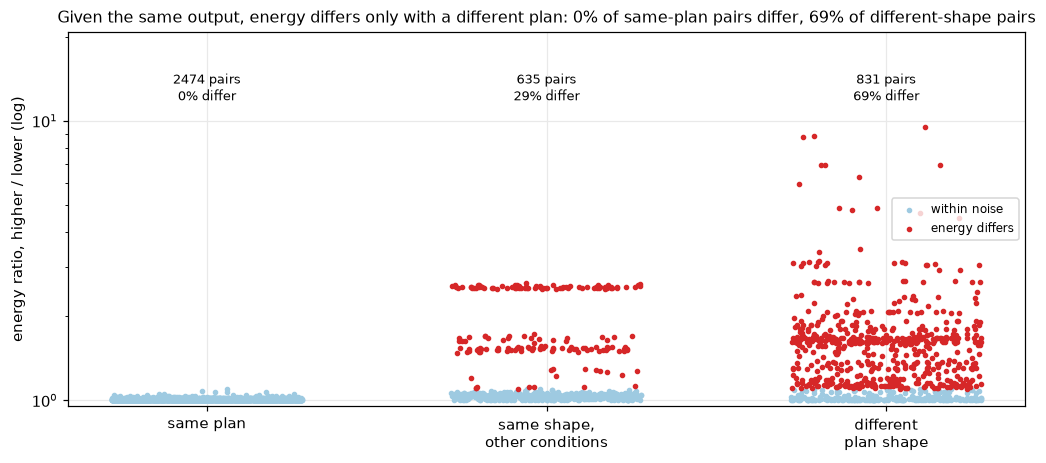

In [8]:
def plan_level(r):
    if r["same plan"]:
        return "same plan"
    if r["same plan shape, other conditions"]:
        return "same shape,\nother conditions"
    return "different\nplan shape"


Sp = Sp.assign(level=Sp.apply(plan_level, axis=1))
LEVELS = ["same plan", "same shape,\nother conditions", "different\nplan shape"]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
rng = np.random.default_rng(0)
for i, lv in enumerate(LEVELS):
    d = Sp[Sp["level"] == lv]
    x = i + rng.uniform(-0.28, 0.28, len(d))
    ax.scatter(x[~d["energy_differs"].to_numpy()], d.loc[~d["energy_differs"], "ratio"], s=7, color="#9ecae1",
               zorder=3, label="within noise" if i == 0 else None)
    ax.scatter(x[d["energy_differs"].to_numpy()], d.loc[d["energy_differs"], "ratio"], s=7, color="#d62728",
               zorder=3, label="energy differs" if i == 0 else None)
    ax.text(i, Sp["ratio"].max() * 1.25, f"{len(d)} pairs\n{100 * d['energy_differs'].mean():.0f}% differ",
            ha="center", fontsize=8.5)
ax.set_yscale("log"); ax.set_ylim(0.95, Sp["ratio"].max() * 2.2)
ax.set_xticks(range(len(LEVELS))); ax.set_xticklabels(LEVELS)
ax.set_ylabel("energy ratio, higher / lower (log)"); ax.legend(fontsize=8, loc="center right")
lv_d = Sp.groupby("level")["energy_differs"].mean()
ax.set_title(f"Given the same output, energy differs only with a different plan: "
             f"{100 * lv_d.get('same plan', 0):.0f}% of same-plan pairs differ, "
             f"{100 * lv_d.get(LEVELS[2], 0):.0f}% of different-shape pairs", fontsize=10.5)
fig.tight_layout(); savefig(fig, "same_output_energy_by_plan"); plt.show()

#### What the more expensive SQL does differently

For the same-output pairs whose energy differs, orient each pair cheaper → more expensive and compare their
SQL features (from `csv/sqlstorm_stackoverflow_query_features.csv`): how often the expensive version has
more of something, and how often the cheaper one does. A large gap between the two columns is a trend.

In [9]:
FCOLS = [("joins", "n_join"), ("tables referenced", "n_tables"), ("SELECTs (subqueries)", "n_select"),
         ("tokens", "tokens")]
BCOLS = [("CTE (WITH)", "is_cte"), ("window (OVER)", "has_window"), ("GROUP BY", "has_group"),
         ("DISTINCT", "has_distinct"), ("LEFT JOIN", "join_left"), ("ORDER BY", "has_order"), ("LIMIT", "has_limit")]
D = Sp[Sp["energy_differs"]].copy()
D["cheap"] = np.where(D["energy_a"] <= D["energy_b"], D["a"], D["b"])
D["dear"] = np.where(D["energy_a"] <= D["energy_b"], D["b"], D["a"])
rows = []
for lbl, c in FCOLS:
    x, y = FEAT.loc[D["dear"], c].to_numpy(), FEAT.loc[D["cheap"], c].to_numpy()
    rows.append({"feature": f"more {lbl}", "expensive has more (%)": 100 * (x > y).mean(),
                 "cheaper has more (%)": 100 * (x < y).mean()})
for lbl, c in BCOLS:
    x, y = FEAT.loc[D["dear"], c].astype(bool).to_numpy(), FEAT.loc[D["cheap"], c].astype(bool).to_numpy()
    rows.append({"feature": f"uses {lbl}", "expensive has more (%)": 100 * (x & ~y).mean(),
                 "cheaper has more (%)": 100 * (~x & y).mean()})
for lbl, k in [("launches parallel workers", "par"), ("spills to disk", "temp"), ("uses a top-N sort", "topn")]:
    x = np.array([PI[q][k] for q in D["dear"]]); y = np.array([PI[q][k] for q in D["cheap"]])
    rows.append({"feature": f"plan {lbl}", "expensive has more (%)": 100 * (x & ~y).mean(),
                 "cheaper has more (%)": 100 * (~x & y).mean()})
bx = np.array([PI[q]["buf"] for q in D["dear"]]); by = np.array([PI[q]["buf"] for q in D["cheap"]])
rows.append({"feature": "plan touches more buffers", "expensive has more (%)": 100 * (bx > by).mean(),
             "cheaper has more (%)": 100 * (bx < by).mean()})
DEAR = pd.DataFrame(rows).set_index("feature")
print(f"{len(D)} same-output pairs whose energy differs (median ratio {D['ratio'].median():.2f}):")
display(DEAR.round(1))

758 same-output pairs whose energy differs (median ratio 1.61):


,expensive has more (%),cheaper has more (%)
feature,,
more joins,6.7,19.9
more tables referenced,4.2,0.4
more SELECTs (subqueries),27.6,2.4
more tokens,45.1,51.2
uses CTE (WITH),1.2,1.6
uses window (OVER),1.1,0.4
uses GROUP BY,0.8,19.3
uses DISTINCT,6.5,1.1
uses LEFT JOIN,4.4,19.3


The largest gaps between SQL texts with the same output, then the largest one in full.

In [10]:
def plan_diff_text(r):
    return ", ".join(k for k in list(PLAN_DIFFS)[2:] if r.get(k) is True) or ("same plan" if r.get("same plan") else "conditions only")


TOP = Sp.sort_values("ratio", ascending=False).head(12)
TOP_T = pd.DataFrame({"cheaper": np.where(TOP["energy_a"] <= TOP["energy_b"], TOP["a"], TOP["b"]),
                      "expensive": np.where(TOP["energy_a"] <= TOP["energy_b"], TOP["b"], TOP["a"]),
                      "relation": TOP["relation"], "rows": TOP["rows_a"],
                      "energy (J)": [f"{min(x, y):.2f} → {max(x, y):.2f}" for x, y in zip(TOP["energy_a"], TOP["energy_b"])],
                      "ratio": TOP["ratio"].round(1), "plan differences": TOP.apply(plan_diff_text, axis=1)})
with pd.option_context("display.max_colwidth", 120):
    display(TOP_T.reset_index(drop=True))
show_pair(int(TOP_T["cheaper"].iloc[0]), int(TOP_T["expensive"].iloc[0]))

,cheaper,expensive,relation,rows,energy (J),ratio,plan differences
0,8669,9931,reordered rows,12,1.09 → 10.33,9.5,"different join methods, different scan methods (same tables)"
1,12226,14153,reordered columns,100,1.11 → 9.77,8.8,"different join methods, different scan methods (same tables)"
2,12226,13636,reordered columns,100,1.11 → 9.74,8.8,"different join methods, different scan methods (same tables)"
3,10271,11575,renamed columns,100,1.37 → 9.52,7.0,"different join methods, different scan methods (same tables)"
4,10271,19767,reordered columns,100,1.37 → 9.47,6.9,"different join methods, different scan methods (same tables)"
5,10271,12809,reordered columns,100,1.37 → 9.47,6.9,"different join methods, different scan methods (same tables)"
6,11137,14426,reordered columns,100,1.99 → 12.46,6.3,"different tables read, different join methods, one uses a top-N sort, one not"
7,5949,32588,reordered columns,27,1.25 → 7.40,5.9,"different tables read, different join methods"
8,10538,14153,reordered columns,100,2.00 → 9.77,4.9,different join methods
9,10538,13636,reordered columns,100,2.00 → 9.74,4.9,different join methods


8669 vs 9931: reordered rows;  energy 1.09 J vs 10.33 J (9.48×);  copies 1 / 1

-- output of 8669 (12 rows, 9 columns)
postid|title|creationdate|viewcount|score|ownername|commentcount|upvotecount|downvotecount
342708||2024-09-30 22:49:43.85||1|Bill Karwin|0|0|0
342707|SSMS's GUI and dbatools produce different scripts for restoring databases in full recovery mode, what practical differences do they have?|2024-09-30 22:4
342445||2024-09-18 13:12:14.573||0|Aaron Bertrand|0|0|0

-- output of 9931 (12 rows, 9 columns)
postid|title|creationdate|score|viewcount|author|commentcount|upvotes|downvotes
342708||2024-09-30 22:49:43.85|1||Bill Karwin|0|0|0
342707|SSMS's GUI and dbatools produce different scripts for restoring databases in full recovery mode, what practical differences do they have?|2024-09-30 22:4
342706|Primary Key data type suggestion for MySQL for an application that depends in a external system. unsigned bigint vs varchar data type in primary keys|202

-- SQL diff
--- 8669
+++ 9

### 3b. Same plan, different output

§3 holds the output fixed: among queries returning the same data, the same plan always meant the same energy.
That does **not** carry over to queries whose outputs differ. The plan key (operators, tables, conditions) leaves
out three things that change how much work a plan does:

* the **`LIMIT` value** — a plain `EXPLAIN` shows a `Limit` node but not its count, and a larger limit runs the
  plan further;
* the **output expressions** — extra aggregates or computed columns are evaluated for every row, and are not in
  the plan text without `EXPLAIN (VERBOSE)`;
* **per-row subqueries** — a correlated subquery in the select list (a `SubPlan`) runs once per returned row, so
  it multiplies the first two.

Here every pair of variants with the same plan (and, separately, the same plan shape) is compared, whatever
they return. *Same output* = same rows (any of the §3 same-output relations, or both empty). The first table
splits by same / different output; the second takes the same-plan, different-output pairs and asks what
differs: the number of rows returned (the plan's actual row count), the number of output columns, and whether
the plan has a per-row subquery.

In [11]:
SAME_REL = {frozenset((a, b)) for a, b, r in zip(REL["a"], REL["b"], REL["relation"]) if r in SAME}


def same_output(a, b):
    return frozenset((a, b)) in SAME_REL or (a in RAW and b in RAW and RAW[a][1] == RAW[b][1])


def has_subplan(q):
    return any((n["label"] or "").startswith("SubPlan") for n in PLANS[q]["nodes"])


VP = [r for r in VAR if r in PLANS and pd.notna(VE.at[r, "energy_j"])]
SUBP = {r: has_subplan(r) for r in VP}
rows = []
for key, col in [("same plan", "plan_hash"), ("same plan shape", "plan_shape_hash")]:
    grp = collections.defaultdict(list)
    for r in VP:
        grp[PL.at[r, col]].append(r)
    for g in grp.values():
        for a, b in itertools.combinations(sorted(g), 2):
            ea, eb = VE.at[a, "energy_j"], VE.at[b, "energy_j"]
            ratio = max(ea, eb) / min(ea, eb)
            rows.append({"key": key, "a": a, "b": b, "same output": same_output(a, b),
                         "energy_a": ea, "energy_b": eb, "ratio": ratio,
                         "energy differs": bool(abs(ea - eb) > 3 * np.hypot(VE.at[a, "energy_se"], VE.at[b, "energy_se"])
                                                and ratio >= 1.1),
                         "rows_a": PL.at[a, "root_rows"], "rows_b": PL.at[b, "root_rows"],
                         "ncol_a": len(RAW[a][0]) if a in RAW else np.nan, "ncol_b": len(RAW[b][0]) if b in RAW else np.nan,
                         "buffers_a": PL.at[a, "shared_hit"] + PL.at[a, "shared_read"],
                         "buffers_b": PL.at[b, "shared_hit"] + PL.at[b, "shared_read"],
                         "per-row subquery": SUBP[a] or SUBP[b]})
SP = pd.DataFrame(rows)
SP["output"] = np.where(SP["same output"], "same output", "different output")
SP_SUM = (SP.groupby(["key", "output"])
          .agg(pairs=("a", "size"), **{"energy differs (%)": ("energy differs", lambda s: 100 * s.mean())},
               **{"median ratio": ("ratio", "median")}, **{"90th pct ratio": ("ratio", lambda s: s.quantile(0.9))},
               **{"largest ratio": ("ratio", "max")}))
display(SP_SUM.round(3))

SPD = SP[(SP["key"] == "same plan") & ~SP["same output"]].copy()
SPD["what differs"] = np.select(
    [SPD["rows_a"] != SPD["rows_b"], SPD["ncol_a"] != SPD["ncol_b"]],
    ["number of rows returned", "same row count, number of columns"], "same row and column count (other values or expressions)")
SPD["buffers ratio"] = SPD[["buffers_a", "buffers_b"]].max(axis=1) / SPD[["buffers_a", "buffers_b"]].min(axis=1).clip(lower=1)
SP_WHY = (SPD.groupby(["what differs", "per-row subquery"])
          .agg(pairs=("a", "size"), **{"energy differs (%)": ("energy differs", lambda s: 100 * s.mean())},
               **{"median ratio": ("ratio", "median")}, **{"largest ratio": ("ratio", "max")},
               **{"median buffers ratio": ("buffers ratio", "median")}))
print(f"Same plan, different output: {len(SPD)} pairs; what differs between the two (rows from the plan's "
      f"actual row count, columns from the output header):")
display(SP_WHY.round(3))
diff = SPD[SPD["energy differs"]]
print(f"Of the {len(diff)} same-plan pairs whose energy differs, the plan with more energy also touches more "
      f"buffers in {100 * ((diff['energy_a'] > diff['energy_b']) == (diff['buffers_a'] > diff['buffers_b'])).mean():.0f}%.")

pairs  energy differs (%)  median ratio  \
key             output                                                      
same plan       different output  25326              13.382         1.025   
                same output        2544               0.000         1.006   
same plan shape different output  63439              24.499         1.042   
                same output        3233               5.691         1.007   

                                  90th pct ratio  largest ratio  
key             output                                           
same plan       different output           1.194          6.303  
                same output                1.016          1.240  
same plan shape different output           1.473         14.772  
                same output                1.052          2.622

Same plan, different output: 25326 pairs; what differs between the two (rows from the plan's actual row count, columns from the output header):


pairs  \
what differs                                       per-row subquery          
number of rows returned                            False              1457   
                                                   True                  2   
same row and column count (other values or expr... False              4518   
                                                   True                  3   
same row count, number of columns                  False             19331   
                                                   True                 15   

                                                                     energy differs (%)  \
what differs                                       per-row subquery                       
number of rows returned                            False                         14.825   
                                                   True                         100.000   
same row and column count (other values or expr... False                         11.797   
                                                   True                           0.000   
same row count, number of columns                  False                         13.646   
                                                   True                           0.000   

                                                                     median ratio  \
what differs                                       per-row subquery                 
number of rows returned                            False                    1.034   
                                                   True                     6.283   
same row and column count (other values or expr... False                    1.011   
                                                   True                     1.016   
same row count, number of columns                  False                    1.028   
                                                   True                     1.005   

                                                                     largest ratio  \
what differs                                       per-row subquery                  
number of rows returned                            False                     1.690   
                                                   True                      6.303   
same row and column count (other values or expr... False                     1.567   
                                                   True                      1.034   
same row count, number of columns                  False                     1.855   
                                                   True                      1.013   

                                                                     median buffers ratio  
what differs                                       per-row subquery                        
number of rows returned                            False                             1.00  
                                                   True                              8.93  
same row and column count (other values or expr... False                             1.00  
                                                   True                              1.00  
same row count, number of columns                  False                             1.00  
                                                   True                              1.00

Of the 3389 same-plan pairs whose energy differs, the plan with more energy also touches more buffers in 54%.


In [12]:
SP_TOP = SPD.sort_values("ratio", ascending=False).head(10)
SP_TOP_T = pd.DataFrame({
    "cheaper": np.where(SP_TOP["energy_a"] <= SP_TOP["energy_b"], SP_TOP["a"], SP_TOP["b"]),
    "expensive": np.where(SP_TOP["energy_a"] <= SP_TOP["energy_b"], SP_TOP["b"], SP_TOP["a"]),
    "energy (J)": [f"{min(x, y):.2f} → {max(x, y):.2f}" for x, y in zip(SP_TOP["energy_a"], SP_TOP["energy_b"])],
    "ratio": SP_TOP["ratio"].round(2),
    "rows": [f"{a:.0f} / {b:.0f}" for a, b in zip(SP_TOP["rows_a"], SP_TOP["rows_b"])],
    "columns": [f"{a:.0f} / {b:.0f}" for a, b in zip(SP_TOP["ncol_a"], SP_TOP["ncol_b"])],
    "buffers": [f"{a / 1e3:.0f} k / {b / 1e3:.0f} k" for a, b in zip(SP_TOP["buffers_a"], SP_TOP["buffers_b"])],
    "per-row subquery": SP_TOP["per-row subquery"], "what differs": SP_TOP["what differs"]})
print("Largest gaps between queries with the same plan (rows, columns and buffers as a / b of the pair):")
display(SP_TOP_T.reset_index(drop=True))
ex = SP_TOP.iloc[0]
print(f"\nThe largest, {int(ex['a'])} vs {int(ex['b'])}, side by side:")
for q in (int(ex["a"]), int(ex["b"])):
    print(f"\n{q}: {VE.at[q, 'energy_j']:.2f} J, {PL.at[q, 'root_rows']:.0f} rows, "
          f"{(PL.at[q, 'shared_hit'] + PL.at[q, 'shared_read']) / 1e3:.0f} k buffers")
    print(sql_body(q)[:900])
print("\nSame plan for both:")
pl_show(int(ex["a"]), cond=False) if "pl_show" in globals() else print(plan_signature(PLANS[int(ex["a"])], False))

Largest gaps between queries with the same plan (rows, columns and buffers as a / b of the pair):


,cheaper,expensive,energy (J),ratio,rows,columns,buffers,per-row subquery,what differs
0,17974,12531,9.71 → 61.23,6.30,100 / 10,11 / 8,2379 k / 266 k,True,number of rows returned
1,16241,12531,9.78 → 61.23,6.26,100 / 10,11 / 7,2379 k / 266 k,True,number of rows returned
2,10113,12537,0.55 → 1.02,1.86,6 / 6,4 / 8,32 k / 32 k,False,"same row count, number of columns"
3,10117,12196,0.66 → 1.19,1.79,6 / 6,2 / 6,32 k / 32 k,False,"same row count, number of columns"
4,17160,14168,3.49 → 5.89,1.69,100 / 10,8 / 5,37 k / 37 k,False,number of rows returned
5,14903,11567,2.05 → 3.43,1.67,1 / 1,11 / 9,43 k / 43 k,False,"same row count, number of columns"
6,12046,12196,0.72 → 1.19,1.65,6 / 6,3 / 6,32 k / 32 k,False,"same row count, number of columns"
7,13568,12196,0.72 → 1.19,1.65,6 / 6,6 / 3,32 k / 32 k,False,"same row count, number of columns"
8,16034,10371,2.31 → 3.81,1.65,100 / 10,10 / 3,37 k / 37 k,False,number of rows returned
9,10065,12196,0.72 → 1.19,1.64,6 / 6,3 / 6,32 k / 32 k,False,"same row count, number of columns"



The largest, 12531 vs 17974, side by side:

12531: 61.23 J, 100 rows, 2379 k buffers
SELECT 
    P.Id AS PostId,
    P.Title,
    P.Score,
    P.ViewCount,
    P.AnswerCount,
    P.CommentCount,
    P.CreationDate,
    U.DisplayName AS OwnerDisplayName,
    (SELECT COUNT(*) 
     FROM Comments C 
     WHERE C.PostId = P.Id) AS TotalComments,
    (SELECT COUNT(*) 
     FROM Votes V 
     WHERE V.PostId = P.Id AND V.VoteTypeId = 2) AS UpVotes,
    (SELECT COUNT(*) 
     FROM Votes V 
     WHERE V.PostId = P.Id AND V.VoteTypeId = 3) AS DownVotes
FROM 
    Posts P
JOIN 
    Users U ON P.OwnerUserId = U.Id
WHERE 
    P.PostTypeId = 1 
ORDER BY 
    P.CreationDate DESC
LIMIT 100;

17974: 9.71 J, 10 rows, 266 k buffers
SELECT 
    p.Id AS PostId,
    p.Title,
    p.CreationDate,
    p.Score,
    u.DisplayName AS OwnerDisplayName,
    (SELECT COUNT(*) FROM Comments c WHERE c.PostId = p.Id) AS CommentCount,
    (SELECT COUNT(*) FROM Votes v WHERE v.PostId = p.Id AND v.VoteTypeId = 2) AS UpVote

**Reading §3 and §3b together.** With the output held fixed, the plan decides the energy: no same-plan pair
differed. Across different outputs, the same plan is a strong grouping but not a guarantee. Most same-plan pairs
still cost the same, and where they do not the gap is usually small — a few percent, rarely above 2× — whatever
differs between the outputs (rows, columns or values). These gaps come from what is computed and returned per
row: more or heavier output expressions, more rows. They do not show in the buffer counts (the same plan reads
the same data, so the extra cost is CPU, not reading), which is why the energy and buffer differences agree only
about half the time. The one large kind is a **per-row subquery combined with a larger `LIMIT`**: the subquery
runs once for every extra row, the buffers grow with it, and the energy gap reaches 6×.

A key that pins energy down therefore needs the plan **plus** the `LIMIT` value and the output expressions
(`EXPLAIN (VERBOSE)` prints the latter). SQL text alone and output alone are not enough either way: §3 shows
the same output at very different cost.

## 4. Renamed versions of the same output

The same data under other column names (and possibly another column order). The table lists the groups of
variants that return the same data, with the column names each one uses; for large groups only the first
names are shown. Energy spread is the max/min of the variants' energies.

In [13]:
REN = REL[REL["relation"].isin(["renamed columns", "reordered columns"])]
parent = {}


def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x


for a, b in zip(REN["a"], REN["b"]):
    parent[find(a)] = find(b)
for a, b in zip(REL.loc[REL["relation"] == "identical", "a"], REL.loc[REL["relation"] == "identical", "b"]):
    if a in parent or b in parent:
        parent[find(a)] = find(b)
groups = collections.defaultdict(list)
for x in list(parent):
    groups[find(x)].append(x)
RG = sorted((sorted(g) for g in groups.values()), key=len, reverse=True)
rows = []
for g in RG:
    e = VE.loc[g, "energy_j"].dropna()
    names = collections.Counter("|".join(sorted(OUT[q].header)) for q in g)
    rows.append({"variants": len(g), "queries": sum(len(VAR[q]) for q in g), "rows": OUT[g[0]].n,
                 "column names used": len(names),
                 "examples of headers": "  /  ".join("|".join(OUT[q].header) for q in g[:3]),
                 "energy min–max (J)": f"{e.min():.2f}–{e.max():.2f}" if len(e) else "",
                 "max/min": e.max() / e.min() if len(e) > 1 else np.nan, "variant ids": " ".join(map(str, g[:8])) + (" …" if len(g) > 8 else "")})
RGT = pd.DataFrame(rows)
print(f"{len(RGT)} groups of renamed or reordered versions ({int(RGT['variants'].sum())} variants, "
      f"{int(RGT['queries'].sum())} queries); max/min energy within a group: median {RGT['max/min'].median():.2f}, "
      f"≥ 1.5× in {int((RGT['max/min'] >= 1.5).sum())} groups")
with pd.option_context("display.max_colwidth", 110):
    display(RGT.head(15).round(2))

213 groups of renamed or reordered versions (922 variants, 3528 queries); max/min energy within a group: median 1.02, ≥ 1.5× in 36 groups


,variants,queries,rows,column names used,examples of headers,energy min–max (J),max/min,variant ids
0,31,291,10,13,displayname|title|creationdate|score|viewcount / title|creationdate|ownerdisplayname|score|viewcount / ...,0.57–0.59,1.04,15015 15049 15055 15075 15157 15184 15190 15223 …
1,23,256,10,8,id|title|ownerdisplayname|creationdate|score|viewcount / postid|title|creationdate|ownerdisplayname|scor...,0.57–0.59,1.03,15021 15033 15054 15088 15124 15197 15265 15279 …
2,22,78,10,10,title|ownerdisplayname|creationdate|score|viewcount|commentcount / posttitle|ownerdisplayname|creationda...,1.41–2.63,1.86,15031 15064 15079 15338 15488 15537 15557 15897 …
3,21,182,10,5,postid|title|ownerdisplayname|creationdate|score|viewcount|commentcount / postid|title|creationdate|owne...,2.33–4.05,1.74,15010 15036 15041 15048 15059 15071 15152 15491 …
4,21,175,10,8,title|creationdate|ownername|commentcount / title|creationdate|displayname|commentcount / displayname|...,1.35–1.42,1.05,15008 15111 15151 15253 15304 15399 15457 15478 …
5,21,57,10,8,userdisplayname|posttitle|postcreationdate|postscore|commentcount / userdisplayname|posttitle|postcreati...,1.32–3.45,2.62,15095 15332 15370 15431 15554 15939 15963 16084 …
6,21,105,10,7,displayname|title|creationdate|score|commentcount / displayname|title|creationdate|score|commentcount /...,1.37–2.67,1.95,15001 15037 15161 15221 15227 15417 15443 15547 …
7,20,215,10,11,postid|title|ownerdisplayname|creationdate|commentcount|upvotes|downvotes / postid|title|creationdate|ow...,4.69–12.52,2.67,15020 15034 15057 15196 15261 15336 15590 15668 …
8,18,143,10,13,title|creationdate|author|commentcount|upvotes|downvotes / title|creationdate|ownername|commentcount|upv...,3.45–4.74,1.38,15005 15080 15123 15236 15252 15812 16644 17181 …
9,17,99,10,7,id|title|score|ownername|creationdate / id|title|creationdate|displayname|score / id|title|displayname...,0.57–0.58,1.01,15026 15035 15046 15141 15215 15238 15288 15311 …


## 5. Limited versions: the same data, fewer rows

A's rows are the first rows of B (nearest step: the B with the fewest extra rows), with all of A's columns or
some of them. Does returning fewer rows save energy, and does the plan change?

In [14]:
L = REL[REL["nearest"] & REL["relation"].isin(["limited", "limited + fewer columns"]) & REL["energy_differs"].notna()].copy()
L["energy_differs"] = L["energy_differs"].astype(bool)
L["row ratio"] = pd.cut(L["rows_b"] / L["rows_a"], [1, 2, 5, 20, np.inf], labels=["≤ 2×", "2–5×", "5–20×", "> 20×"],
                        include_lowest=True)
L["B reads other tables"] = L["different tables read"].astype(bool)
LIM = (L.groupby(["relation", "B reads other tables"], observed=True)
       .agg(pairs=("a", "size"), **{"median energy B/A": ("b_over_a", "median")},
            **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())},
            **{"same plan shape (%)": ("same plan shape, other conditions", lambda s: 100 * (s.astype(bool) | L.loc[s.index, "same plan"].astype(bool)).mean())}))
display(LIM.round(2))
LIM_ROWS = (L[L["relation"] == "limited"].groupby("row ratio", observed=True)
            .agg(pairs=("a", "size"), **{"median energy B/A": ("b_over_a", "median")},
                 **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())}))
print("'limited' only (same columns), by how many more rows B returns:")
display(LIM_ROWS.round(2))

pairs  median energy B/A  \
relation                B reads other tables                             
limited                 False                   270               1.00   
                        True                     59               1.03   
limited + fewer columns False                   214               1.13   
                        True                    946               2.87   

                                              energy differs (%)  \
relation                B reads other tables                       
limited                 False                              34.81   
                        True                               81.36   
limited + fewer columns False                              65.89   
                        True                               94.93   

                                              same plan shape (%)  
relation                B reads other tables                       
limited                 False                               45.19  
                        True                                 1.69  
limited + fewer columns False                               30.84  
                        True                                 0.42

'limited' only (same columns), by how many more rows B returns:


,pairs,median energy B/A,energy differs (%)
row ratio,,,
≤ 2×,19,1.01,73.68
2–5×,40,1.00,27.50
5–20×,208,1.00,30.77
> 20×,62,1.50,85.48


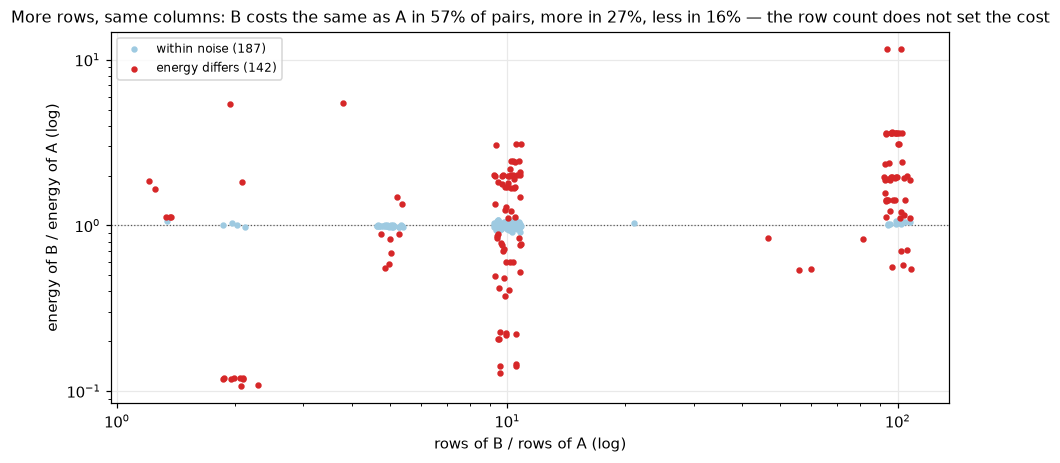

19215 vs 8021: limited;  energy 0.57 J vs 6.65 J (11.68×);  copies 1 / 1

-- output of 19215 (10 rows, 8 columns)
postid|title|creationdate|ownerdisplayname|score|viewcount|answercount|commentcount
1285|How do I list all databases and tables using psql?|2011-02-17 08:45:49.61|Jonas|1572|3260864|9|0
22362|List all columns for a specified table|2012-08-13 12:44:44.887|Stephane Rolland|566|1211394|5|0
9306|How do you mysqldump specific table(s)?|2011-12-16 20:39:37.727|markdorison|546|1042515|4|2

-- output of 8021 (1000 rows, capped, 8 columns)
postid|title|creationdate|score|viewcount|ownerdisplayname|commentcount|answercount
1285|How do I list all databases and tables using psql?|2011-02-17 08:45:49.61|1572|3260864|Jonas|0|9
22362|List all columns for a specified table|2012-08-13 12:44:44.887|566|1211394|Stephane Rolland|0|5
9306|How do you mysqldump specific table(s)?|2011-12-16 20:39:37.727|546|1042515|markdorison|2|4

-- SQL diff
--- 19215
+++ 8021
@@ -1,18 +1,45 @@
+WITH RankedPost

In [15]:
Lo = L[L["relation"] == "limited"]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
jit = np.exp(np.random.default_rng(1).uniform(-0.08, 0.08, len(Lo)))       # spread the stacked row ratios
for flag, col, lbl in [(False, "#9ecae1", "within noise"), (True, "#d62728", "energy differs")]:
    m = (Lo["energy_differs"] == flag).to_numpy()
    d = Lo[m]
    ax.scatter(d["rows_b"] / d["rows_a"] * jit[m], d["b_over_a"], s=10, color=col, label=f"{lbl} ({len(d)})", zorder=3)
ax.axhline(1, color="#555", lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("rows of B / rows of A (log)"); ax.set_ylabel("energy of B / energy of A (log)")
ax.legend(fontsize=8)
more = 100 * (Lo["energy_differs"] & (Lo["b_over_a"] > 1)).mean()
less = 100 * (Lo["energy_differs"] & (Lo["b_over_a"] < 1)).mean()
ax.set_title(f"More rows, same columns: B costs the same as A in {100 - more - less:.0f}% of pairs, more in "
             f"{more:.0f}%, less in {less:.0f}% — the row count does not set the cost", fontsize=10.5)
fig.tight_layout(); savefig(fig, "limited_energy"); plt.show()
ex = Lo.sort_values("b_over_a", ascending=False).iloc[0]
show_pair(int(ex["a"]), int(ex["b"]))

## 6. Narrower versions: the same rows, fewer columns

A's columns are some of B's columns over the same rows (nearest step: the B with the fewest extra columns).
The extra columns of B often come from extra joins — a count of comments, a sum of votes — so the table splits
the pairs by whether B's plan reads tables A's does not.

In [16]:
W = REL[REL["nearest"] & REL["relation"].isin(["fewer columns", "fewer columns, reordered rows"]) & REL["energy_differs"].notna()].copy()
W["energy_differs"] = W["energy_differs"].astype(bool)
W["B reads other tables"] = W["different tables read"].astype(bool)
W["extra columns"] = pd.cut(W["ncol_b"] - W["ncol_a"], [0, 1, 2, 4, np.inf], labels=["1", "2", "3–4", "5+"])
WID = (W.groupby(["B reads other tables", "extra columns"], observed=True)
       .agg(pairs=("a", "size"), **{"median energy B/A": ("b_over_a", "median")},
            **{"energy differs (%)": ("energy_differs", lambda s: 100 * s.mean())},
            **{"B more expensive (%)": ("b_over_a", lambda s: 100 * (s > 1).mean())}))
display(WID.round(2))
WD = W[W["energy_differs"]]
print(f"\nPlan differences in the {len(WD)} narrower/wider pairs whose energy differs (%):")
display((100 * WD[list(PLAN_DIFFS)].astype(float).mean()).round(1).to_frame("pairs with it (%)"))
ex = W[~W["B reads other tables"]].sort_values("b_over_a", ascending=False).iloc[0]
print("\nLargest gap where B reads no extra table:")
show_pair(int(ex["a"]), int(ex["b"]))

pairs  median energy B/A  \
B reads other tables extra columns                             
False                1                581               1.02   
                     2                 75               1.10   
                     3–4               27               1.14   
                     5+                 6               1.23   
True                 1                300               1.95   
                     2                 99               1.16   
                     3–4              112               2.08   
                     5+                81               3.03   

                                    energy differs (%)  B more expensive (%)  
B reads other tables extra columns                                            
False                1                           32.53                 79.86  
                     2                           53.33                 93.33  
                     3–4                         81.48                 77.78  
                     5+                         100.00                 83.33  
True                 1                           80.00                 80.00  
                     2                           79.80                 74.75  
                     3–4                         88.39                 78.57  
                     5+                          98.77                 96.30


Plan differences in the 755 narrower/wider pairs whose energy differs (%):


,pairs with it (%)
same plan,3.8
"same plan shape, other conditions",3.2
different tables read,66.0
different join methods,80.1
different scan methods (same tables),17.4
"one parallel, one not",38.0
"one spills to disk, one not",7.9
"one uses a top-N sort, one not",33.2



Largest gap where B reads no extra table:
12902 vs 13717: fewer columns, reordered rows;  energy 3.61 J vs 46.23 J (12.80×);  copies 1 / 1

-- output of 12902 (1000 rows, capped, 10 columns)
postid|title|ownerdisplayname|creationdate|viewcount|score|answercount|commentcount|badgecount|votecount
342708||Bill Karwin|2024-09-30 22:49:43.85||1||0|75|0
342707|SSMS's GUI and dbatools produce different scripts for restoring databases in full recovery mode, what practical differences do they have?|J. Mini|2024-09
342706|Primary Key data type suggestion for MySQL for an application that depends in a external system. unsigned bigint vs varchar data type in primary keys|Luc

-- output of 13717 (1000 rows, capped, 11 columns)
postid|title|postcreationdate|viewcount|score|answercount|ownerdisplayname|votecount|commentcount|lastbadgedate|badgecount
342708||2024-09-30 22:49:43.85||1||Bill Karwin|0|0|2024-08-05 20:49:30.187|75
342707|SSMS's GUI and dbatools produce different scripts for restoring dat

## 7. Subsets: some of the same rows

Every row of A is a row of B, but not B's first rows — a stricter filter, or another order before a limit.

In [17]:
U = REL[REL["nearest"] & (REL["relation"] == "subset of rows") & REL["energy_differs"].notna()].copy()
U["energy_differs"] = U["energy_differs"].astype(bool)
print(f"{len(U)} nearest-step subset pairs: median energy B/A {U['b_over_a'].median():.2f}, energy differs in "
      f"{100 * U['energy_differs'].mean():.0f}%, B returns median {(U['rows_b'] / U['rows_a']).median():.1f}× the rows")
display((100 * U[list(PLAN_DIFFS)].astype(float).mean()).round(1).to_frame("pairs with it (%)"))
ex = U.sort_values("ratio", ascending=False).iloc[0]
show_pair(int(ex["a"]), int(ex["b"]))

103 nearest-step subset pairs: median energy B/A 0.98, energy differs in 80%, B returns median 10.0× the rows


,pairs with it (%)
same plan,1.0
"same plan shape, other conditions",5.8
different tables read,62.1
different join methods,71.8
different scan methods (same tables),12.6
"one parallel, one not",40.8
"one spills to disk, one not",3.9
"one uses a top-N sort, one not",58.3


18654 vs 8689: subset of rows;  energy 12.52 J vs 1.09 J (0.09×);  copies 1 / 1

-- output of 18654 (10 rows, 7 columns)
postid|title|creationdate|author|totalcomments|totalupvotes|totaldownvotes
342707|SSMS's GUI and dbatools produce different scripts for restoring databases in full recovery mode, what practical differences do they have?|2024-09-30 22:4
342706|Primary Key data type suggestion for MySQL for an application that depends in a external system. unsigned bigint vs varchar data type in primary keys|202
342704|Varbinary column taking lots of space|2024-09-30 18:22:14.783|PhillysDBA|0|0|1

-- output of 8689 (20 rows, 7 columns)
postid|title|creationdate|authordisplayname|commentcount|upvotecount|downvotecount
342708||2024-09-30 22:49:43.85|Bill Karwin|0|0|0
342707|SSMS's GUI and dbatools produce different scripts for restoring databases in full recovery mode, what practical differences do they have?|2024-09-30 22:4
342706|Primary Key data type suggestion for MySQL for an applic

## 8. Export

`csv/sqlstorm_stackoverflow_output_relations.csv`: every same-output pair (§3–4) and every nearest-step
containment pair (§5–7). Queries are the representatives of their copy sets (`a_copies` / `b_copies` list
all query numbers of each set); A is the side with fewer rows. Energies are laptop 2 slope energies (median
over copies); the plan columns compare the two `EXPLAIN ANALYZE` plans.

In [18]:
X = REL[REL["nearest"]].copy()
X["a_copies"] = X["a"].map(lambda q: ";".join(map(str, VAR[q])))
X["b_copies"] = X["b"].map(lambda q: ";".join(map(str, VAR[q])))
X["plan_differences"] = X.apply(lambda r: plan_diff_text(r) if r["a"] in PI and r["b"] in PI else "", axis=1)
cols = ["a", "b", "relation", "a_copies", "b_copies", "rows_a", "rows_b", "ncol_a", "ncol_b", "capped",
        "energy_a", "energy_b", "b_over_a", "energy_differs", "same plan", "same plan shape, other conditions",
        "plan_differences", "buffers_ratio"]
X = X[cols].rename(columns={"a": "query_a", "b": "query_b", "energy_a": "energy_a_j", "energy_b": "energy_b_j",
                            "b_over_a": "energy_b_over_a", "same plan": "same_plan",
                            "same plan shape, other conditions": "same_plan_shape_other_conditions"})
X = X.sort_values(["relation", "query_a", "query_b"])
X.to_csv("csv/sqlstorm_stackoverflow_output_relations.csv", index=False)
print(f"wrote csv/sqlstorm_stackoverflow_output_relations.csv ({len(X)} rows)")
display(X["relation"].value_counts().to_frame("rows"))

wrote csv/sqlstorm_stackoverflow_output_relations.csv (6834 rows)


,rows
relation,
reordered columns,2766
limited + fewer columns,1172
fewer columns,1119
renamed columns,825
limited,329
identical,293
"fewer columns, reordered rows",170
subset of rows,103
reordered rows,57


## 9. Text files for the largest gaps

For reading the cases side by side outside the notebook. Variants are grouped three ways:

* **same plan** — same operators, tables and conditions (§3b);
* **same plan shape** — same operators and tables, conditions may differ;
* **same output** — the same rows, whatever the plan: identical, renamed or reordered columns, reordered rows
  (§3; groups joined through those relations; empty results left out).

In each group the gap is the most expensive variant's energy over the cheapest's; only gaps beyond the noise
rule of §3 count. The 20 groups with the largest gap, per kind, are written to
`export/similar_output_pairs/<kind>/`:

* `NN_pair_<cheapest>_vs_<expensive>.txt` — the group summary at the top (size, energy min / median / max,
  distinct plans and outputs), then the two SQL statements with their energy, rows, columns, plan time and
  buffers, the first rows of each output, and the plans;
* `NN_group.txt` — when the group has more than 2 variants: the same summary, a table of every variant sorted by
  energy, then every SQL statement in that order.

Ranking groups rather than pairs keeps one large group from filling the list. `index.csv` lists all files.

In [19]:
import shutil
PAIR_DIR = Path("export/similar_output_pairs")
TOP_N = 20
KIND_DESC = {"same_plan": "same plan (operators, tables and conditions)",
             "same_plan_shape": "same plan shape (operators and tables; conditions may differ)",
             "same_output": "same output (same rows: identical, renamed or reordered columns, reordered rows)"}


def union_groups(pairs):
    parent = {}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for a, b in pairs:
        parent[find(a)] = find(b)
    g = collections.defaultdict(list)
    for x in list(parent):
        g[find(x)].append(x)
    return list(g.values())


def groups_by(col):
    g = collections.defaultdict(list)
    for r in VP:
        g[PL.at[r, col]].append(r)
    return list(g.values())


has_e = set(VE.index[VE["energy_j"].notna()])
GROUPS = {"same_plan": groups_by("plan_hash"), "same_plan_shape": groups_by("plan_shape_hash"),
          "same_output": union_groups((a, b) for a, b, r in zip(REL["a"], REL["b"], REL["relation"]) if r in SAME)}
GROUPS = {k: [sorted((q for q in g if q in has_e), key=lambda q: VE.at[q, "energy_j"]) for g in v] for k, v in GROUPS.items()}
GROUPS = {k: [g for g in v if len(g) >= 2] for k, v in GROUPS.items()}


def gap(g):
    lo, hi = g[0], g[-1]
    elo, ehi = VE.at[lo, "energy_j"], VE.at[hi, "energy_j"]
    beyond = abs(ehi - elo) > 3 * np.hypot(VE.at[lo, "energy_se"], VE.at[hi, "energy_se"]) and ehi / elo >= 1.1
    return ehi / elo, beyond


def n_queries(g):
    return sum(len(VAR[q]) for q in g)


def out_key(q):
    return h(RAW[q][1]) if q in RAW else None


def summary(kind, rank, g):
    e = VE.loc[g, "energy_j"]
    plans = PL.loc[[q for q in g if q in PL.index]]
    outs = {out_key(q) for q in g if out_key(q) is not None}
    return [f"SQLStorm StackOverflow — {KIND_DESC[kind]}",
            f"rank {rank} of {TOP_N} by energy gap within the group (most expensive / cheapest)",
            "",
            f"group:   {len(g)} SQL variants, {n_queries(g)} query files (copies of one SQL text count as one variant)",
            f"energy:  min {e.min():.3f} J   median {e.median():.3f} J   max {e.max():.3f} J   ->  {e.max() / e.min():.2f}x",
            f"         (laptop 2 slope energy per copy; a variant's energy is the median over its copies)",
            f"plans:   {plans['plan_hash'].nunique()} distinct plan(s), {plans['plan_shape_hash'].nunique()} distinct plan shape(s)",
            f"outputs: {len(outs)} distinct result(s) (rows compared, column names ignored)"
            + ("" if len(outs) == sum(q in RAW for q in g) else f" over {sum(q in RAW for q in g)} saved outputs"),
            f"members: {' '.join(map(str, g[:40]))}{' …' if len(g) > 40 else ''}  (cheapest first)"]


def facts(q):
    cp = VAR[q]
    line = [f"query {q}" + (f"   (copies: {' '.join(map(str, cp))})" if len(cp) > 1 else ""),
            f"energy {VE.at[q, 'energy_j']:.3f} J ± {VE.at[q, 'energy_se']:.3f}"]
    if q in M.index and M.at[q, "status"] in ("ok", "capped"):
        line.append(f"output {int(M.at[q, 'rows'])} rows{' (capped at 1000 lines)' if M.at[q, 'status'] == 'capped' else ''}, "
                    f"{int(M.at[q, 'ncol'])} columns")
    if q in PL.index:
        line.append(f"plan: execution {PL.at[q, 'exec_ms']:.0f} ms, {PL.at[q, 'plan_nodes']} nodes, buffers "
                    f"{(PL.at[q, 'shared_hit'] + PL.at[q, 'shared_read']) / 1e3:.0f} k, parallel workers {PL.at[q, 'workers']}"
                    f"{', per-row subquery' if q in PLANS and has_subplan(q) else ''}")
    return line


def output_head(q, n=5):
    if q not in RAW:
        return ["(no saved output)"]
    hdr, recs, _ = RAW[q]
    return ["|".join(hdr)] + [r.replace("\n", " ")[:200] for r in recs[:n]] + (["…"] if len(recs) > n else [])


def block(title, q):
    bar = "=" * 100
    return [bar, f"{title}: query {q}", bar, *facts(q), "", "-- SQL", sql_body(q), "", "-- first rows of the output",
            *output_head(q), ""]


def plan_text(q):
    return plan_signature(PLANS[q]).splitlines() if q in PLANS else ["(no plan)"]


if PAIR_DIR.exists():
    shutil.rmtree(PAIR_DIR)
index = []
for kind, groups in GROUPS.items():
    d = PAIR_DIR / kind
    d.mkdir(parents=True)
    ranked = sorted((g for g in groups if gap(g)[1]), key=lambda g: gap(g)[0], reverse=True)[:TOP_N]
    for rank, g in enumerate(ranked, 1):
        lo, hi = g[0], g[-1]
        head = summary(kind, rank, g)
        gfile = f"{rank:02d}_group.txt" if len(g) > 2 else ""
        if gfile:
            head.append(f"all {len(g)} statements: {gfile}")
        txt = head + ["", f"The two below are the cheapest and the most expensive of the group "
                          f"({VE.at[lo, 'energy_j']:.3f} J vs {VE.at[hi, 'energy_j']:.3f} J).", ""]
        txt += block("CHEAPEST", lo) + block("MOST EXPENSIVE", hi)
        if kind == "same_plan" and lo in PLANS:
            txt += ["=" * 100, "PLAN (the same for both; LIMIT values and output expressions are not shown in it)",
                    "=" * 100, *plan_text(lo), ""]
        else:
            txt += ["=" * 100, f"PLAN of {lo} (cheapest)", "=" * 100, *plan_text(lo), "",
                    "=" * 100, f"PLAN of {hi} (most expensive)", "=" * 100, *plan_text(hi), ""]
            if lo in PLANS and hi in PLANS:
                dd = list(difflib.unified_diff(plan_text(lo), plan_text(hi), str(lo), str(hi), lineterm="", n=0))
                txt += ["=" * 100, "PLAN DIFFERENCE", "=" * 100, *(dd or ["(same plan)"]), ""]
        pfile = f"{rank:02d}_pair_{lo}_vs_{hi}.txt"
        (d / pfile).write_text("\n".join(txt) + "\n", encoding="utf-8")
        if gfile:
            tab = pd.DataFrame([{"variant": q, "copies": len(VAR[q]), "energy (J)": round(VE.at[q, "energy_j"], 3),
                                 "x cheapest": round(VE.at[q, "energy_j"] / VE.at[lo, "energy_j"], 2),
                                 "rows": int(M.at[q, "rows"]) if q in M.index and M.at[q, "status"] in ("ok", "capped") else None,
                                 "columns": int(M.at[q, "ncol"]) if q in M.index and M.at[q, "status"] in ("ok", "capped") else None,
                                 "plan ms": round(PL.at[q, "exec_ms"]) if q in PL.index else None,
                                 "buffers (k)": round((PL.at[q, "shared_hit"] + PL.at[q, "shared_read"]) / 1e3) if q in PL.index else None,
                                 "plan": PL.at[q, "plan_hash"][:8] if q in PL.index else ""} for q in g])
            gtxt = summary(kind, rank, g) + ["", f"pair file: {pfile}", "",
                                             "Every variant, cheapest first ('plan' = first 8 characters of its plan key):",
                                             tab.to_string(index=False), ""]
            for i, q in enumerate(g, 1):
                gtxt += ["=" * 100, f"{i}/{len(g)}  " + "   ".join(facts(q)), "=" * 100, sql_body(q), ""]
            (d / gfile).write_text("\n".join(gtxt) + "\n", encoding="utf-8")
        index.append({"kind": kind, "rank": rank, "variants": len(g), "queries": n_queries(g),
                      "cheapest": lo, "most expensive": hi, "energy min (J)": VE.at[lo, "energy_j"],
                      "energy max (J)": VE.at[hi, "energy_j"], "ratio": VE.at[hi, "energy_j"] / VE.at[lo, "energy_j"],
                      "pair file": f"{kind}/{pfile}", "group file": f"{kind}/{gfile}" if gfile else ""})
IDX = pd.DataFrame(index)
IDX.to_csv(PAIR_DIR / "index.csv", index=False)
for kind in GROUPS:
    n_g = len(GROUPS[kind]); n_b = sum(gap(g)[1] for g in GROUPS[kind])
    print(f"{kind:16} {n_g:5} groups of ≥ 2 variants with energy, {n_b:5} with a gap beyond noise; "
          f"wrote the top {int((IDX['kind'] == kind).sum())}")
print(f"\n{len(list(PAIR_DIR.rglob('*.txt')))} text files and index.csv in {PAIR_DIR}/")
display(IDX.round(3))

same_plan          276 groups of ≥ 2 variants with energy,    78 with a gap beyond noise; wrote the top 20
same_plan_shape    479 groups of ≥ 2 variants with energy,   286 with a gap beyond noise; wrote the top 20
same_output        253 groups of ≥ 2 variants with energy,    77 with a gap beyond noise; wrote the top 20

104 text files and index.csv in export\similar_output_pairs/


,kind,rank,variants,queries,cheapest,most expensive,energy min (J),energy max (J),ratio,pair file,group file
0,same_plan,1,3,4,17974,12531,9.714,61.232,6.303,same_plan/01_pair_17974_vs_12531.txt,same_plan/01_group.txt
1,same_plan,2,2,2,10113,12537,0.548,1.016,1.855,same_plan/02_pair_10113_vs_12537.txt,
2,same_plan,3,53,168,10117,12196,0.663,1.188,1.791,same_plan/03_pair_10117_vs_12196.txt,same_plan/03_group.txt
3,same_plan,4,3,3,17160,14168,3.485,5.890,1.690,same_plan/04_pair_17160_vs_14168.txt,same_plan/04_group.txt
4,same_plan,5,2,2,14903,11567,2.053,3.432,1.672,same_plan/05_pair_14903_vs_11567.txt,
5,same_plan,6,22,25,16034,10371,2.307,3.806,1.650,same_plan/06_pair_16034_vs_10371.txt,same_plan/06_group.txt
6,same_plan,7,10,13,10216,13171,2.900,4.568,1.575,same_plan/07_pair_10216_vs_13171.txt,same_plan/07_group.txt
7,same_plan,8,191,1090,17227,19323,0.552,0.863,1.562,same_plan/08_pair_17227_vs_19323.txt,same_plan/08_group.txt
8,same_plan,9,2,2,12817,14981,4.937,7.454,1.510,same_plan/09_pair_12817_vs_14981.txt,
9,same_plan,10,3,3,10472,14397,5.315,7.834,1.474,same_plan/10_pair_10472_vs_14397.txt,same_plan/10_group.txt
